In [1]:
from dptb.nn.dftbsk import DFTBSK
from ase.io import read
from dptb.data import AtomicData, AtomicDataDict
from dptb.utils.tools import j_loader
import torch
from dptb.postprocess.bandstructure.band import Band
from dptb.nn.dftb.atomicdft import DFT2SKTable
from dptb.nn.build import build_model
from dptb.nn.dftb.sk_param import SKParam
from dptb.nn.sktb.cov_radiiDB import Covalent_radii
Bohr2Ang = 0.529177210903

TBPLaS is not installed. Thus the TBPLaS is not available, Please install it first.


In [2]:
skt = DFT2SKTable(xc='LDA', superposition='density', scalarrel=True, cal_eig_U=True, output='sk20251')

In [3]:
skt.update_config(
    basis={"B": ["2s", "2p"], "N": ["2s", "2p"]}, 
    rw={"B": 2*Covalent_radii['B']/Bohr2Ang, "N": 2*Covalent_radii['N']/Bohr2Ang},
    pw={"B": 2, "N": 2},
    rd={"B": 4*Covalent_radii['B']/Bohr2Ang, "N": 4*Covalent_radii['N']/Bohr2Ang},
    pd={"B": 2, "N": 2}
)



*****************************************************
Scalar-relativistic all-electron LDA calculator for B
*****************************************************
max 1 nodes, 1000 grid points
*****************************************************
Scalar-relativistic all-electron LDA calculator for N
*****************************************************
max 1 nodes, 1000 grid points


In [4]:
skt.atomic_objs

{'B': {'basis': ['2s', '2p'],
  'rd': 6.349479778742587,
  'pd': 2,
  'rw': 3.1747398893712937,
  'pw': 2,
  'atomdft': <hotcent.atomic_dft.AtomicDFT at 0x7f616c9d37f0>,
  'run_completed': False,
  'eigenvalues': {'2s': -0.3440895225468277, '2p': -0.13578969445956232},
  'occupations': {'2s': 2, '2p': 1},
  'hubbardvalues': {'2s': 0.3167716125780692, '2p': 0.288498810740869}},
 'N': {'basis': ['2s', '2p'],
  'rd': 5.366822193937187,
  'pd': 2,
  'rw': 2.6834110969685936,
  'pw': 2,
  'atomdft': <hotcent.atomic_dft.AtomicDFT at 0x7f627821ff40>,
  'run_completed': False,
  'eigenvalues': {'2s': -0.6765018763552579, '2p': -0.2659247397236022},
  'occupations': {'2s': 2, '2p': 3},
  'hubbardvalues': {'2s': 0.4411139450601196, '2p': 0.41787874596343233}}}

In [5]:
Covalent_radii['N']

0.71

In [6]:
4*Covalent_radii['B']/Bohr2Ang, 4*Covalent_radii['N']/Bohr2Ang

(6.349479778742587, 5.366822193937187)

In [7]:
skt.get_full_pair('B', 'N')

Initial run without any confinement
for pre-converging subshells and eigenvalues

Start iteration...
iter   0, dn=4.2e+00>1.0e-07, max 7 sp-iter
iter  10, dn=6.7e-02>1.0e-07, max 3 sp-iter
iter  20, dn=2.1e-03>1.0e-07, max 2 sp-iter
iter  30, dn=1.2e-04>1.0e-07, max 2 sp-iter
iter  40, dn=1.4e-05>1.0e-07, max 1 sp-iter
iter  50, dn=1.6e-06>1.0e-07, max 1 sp-iter
iter  60, dn=1.9e-07>1.0e-07, max 1 sp-iter

valence subshell eigenvalues:
-----------------------------
  2s:   -0.344785962285
  2p:   -0.136621426402

energy contributions:
----------------------------------------
sum of eigenvalues:     -13.952824886335
Hartree energy:         11.504894395092
vxc correction:         -4.636811173058
exchange-corr. energy:  -3.523388780853
----------------------------------------
total energy:           -24.344296889222

converged in 63 iterations
   5.0008 electrons, should be    5.0000
Applying PowerConfinement(r0=3.174740, s=2.000000, ubound=1.0e+04)
to get a confined 2s subshell
Confined 

In [8]:
skt.off2c.plot()

<Figure size 640x480 with 0 Axes>

In [9]:
#sk_path = './slakos/skparams.pth'
sk_path = "./sk20251"
basis = {'B':['2s','2p'],"N":["2s","2p"]}
model2 = DFTBSK(basis=basis, skdata=sk_path,overlap=True)

In [10]:
common_options={
            "basis": {
                "B": ["2s", "2p"],
                "N": ["2s", "2p"]
            },
            "device": "cpu",
            "dtype": "float32",
            "overlap": True,
            "seed": 42
    }
model_options={
        "dftbsk": {
            "skdata":sk_path
        }
    }
model = build_model(common_options=common_options, model_options=model_options)

In [11]:
model.model_options["dftbsk"]

{'skdata': './sk20251'}

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 6.349479778742587, 'N': 5.366822193937187}
This is very dangerous, please make sure you know what you are doing.


/opt/mamba/envs/unisk-dev/lib/python3.10/site-packages/torch/nested/__init__.py:107: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  return torch._nested_tensor_from_tensor_list(ts, dtype, None, device, None)
eig_solver is not set, using default 'torch'.


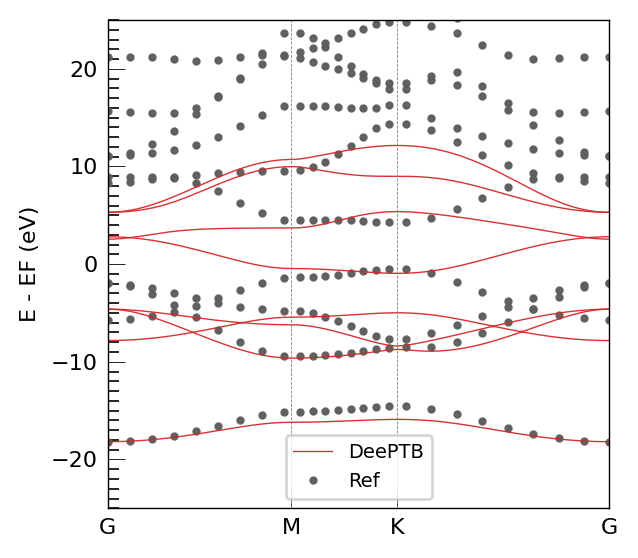

In [12]:
jdata = j_loader("./run/band.json")
results_path = "./band_plot"
kpath_kwargs = jdata["task_options"]
stru_data = "./data/struct.vasp"
AtomicData_options = {"r_max": {'B': 6.349479778742587, 'N': 5.366822193937187}}
structase = read(stru_data)
#data = AtomicData.from_ase(structase, **AtomicData_options)
#data = AtomicData.to_AtomicDataDict(data)
#data = model.idp(data)
bcal = Band(model=model2, 
            use_gui=False, 
            results_path='./', 
            device=model2.device)
eigenstatus = bcal.get_bands(data=stru_data, 
               kpath_kwargs=kpath_kwargs, 
               AtomicData_options=AtomicData_options)
bcal.band_plot(ref_band = kpath_kwargs["ref_band"],
               E_fermi = -2,
               emin = -25,
               emax = 25)

In [13]:
skp = SKParam(basis=common_options['basis'],skdata=sk_path)

In [14]:
skp.skdict.keys()

dict_keys(['Distance', 'Hopping', 'Overlap', 'OnsiteE'])

In [15]:
skp.skdict['OnsiteE']

tensor([[[ -9.3631],
         [ -3.6950]],

        [[-18.4085],
         [ -7.2362]]])

In [17]:
from sympy import Range


(skp.skdict['OnsiteE'][0][skp.skdict['Occu'][0] > 0])
# 根据skp.skdict['Occu'] > 0，找到对应指标skp.skdict['OnsiteE']的部分数值
# 并且根据skp.skdict['OnsiteE']的数值，找到对应最大的数值的指标
highest_occpy_hubbard_u2 = []
for ia in range(len(skp.skdict['OnsiteE'])):
    tarind=0
    for ind in range(len(skp.skdict['OnsiteE'][ia][skp.skdict['Occu'][ia] > 0])):
        val = skp.skdict['OnsiteE'][0][skp.skdict['Occu'][ia] > 0][ind]
        if ind == tarind:
            tarval = val
        else:
            if val > tarval:
                tarind = ind
                tarval = val
    skp.skdict['Occu']
    highest_occpy_hubbard_u = skp.skdict['HubdU'][ia][skp.skdict['Occu'][ia] > 0][tarind]
    highest_occpy_hubbard_u2.append(highest_occpy_hubbard_u)


KeyError: 'Occu'

In [ ]:
skp.skdict['HubdU'].shape

torch.Size([2, 2, 1])

In [ ]:
highest_occpy_hubbard_u2

[tensor(7.8530), tensor(11.5252)]

In [ ]:
tarind,skp.skdict['HubdU']

(1,
 tensor([[[10.1779],
          [ 7.8530]],
 
         [[14.0181],
          [11.5252]]]))

In [ ]:
(skp.skdict['OnsiteE'][0][skp.skdict['Occu'][0] > 0])

tensor([-9.3830, -3.7138])

In [ ]:
skp.skdict['Occu'][0] > 0

tensor([[True],
        [True]])

In [ ]:
skp.idp_sk.chemical_symbol_to_type

{'B': 0, 'N': 1}

In [ ]:
import torch

highest_occpy_hubbard_u = torch.zeros(len(skp.skdict['OnsiteE']),1,1)
for ia in range(len(skp.skdict['OnsiteE'])):
    # 1. 为当前的 `ia` 生成专属的布尔遮罩 (mask)
    # 这是根据您的说明修正的关键部分
    mask_ia = skp.skdict['Occu'][ia] > 0
    # 2. 使用遮罩筛选当前的 OnsiteE 行
    filtered_onsite_e = skp.skdict['OnsiteE'][ia][mask_ia]
    # 3. 安全检查：如果遮罩后没有留下任何元素，则跳过此次循环
    #    这可以防止在空张量上调用 argmax 而引发错误
    if filtered_onsite_e.numel() == 0:
        continue
    # 4. 在筛选后的张量中，高效地找到最大值的索引
    max_idx = torch.argmax(filtered_onsite_e)
    hubbard_u_val = skp.skdict['HubdU'][ia][mask_ia][max_idx].item()
    highest_occpy_hubbard_u[ia,0,0] = hubbard_u_val





In [ ]:
import torch
mask = skp.skdict['Occu'] > 0
onsite_e_for_argmax = skp.skdict['OnsiteE'].clone()
# 3. 将不满足条件的位置设置为负无穷大  torch.where(condition, value_if_true, value_if_false) 这样在 argmax 中，这些被屏蔽的位置就永远不会是最大值
onsite_e_for_argmax = torch.where(mask, onsite_e_for_argmax, torch.tensor(float('-inf')))
# 4. 沿每个 ia (即每行) 查找最大值的索引 dim=1 表示在第二个维度 (轨道维度) 上操作 =True 保持输出维度为 (num_ia, 1)，方便后续 gather 操作
max_indices = torch.argmax(onsite_e_for_argmax, dim=1, keepdim=True)
# 5. 使用 gather 从 HubdU 中并行取出所有对应的值 torch.gather(input, dim, index) -> 根据 index 从 input 中取值
highest_occpy_hubbard_u = torch.gather(skp.skdict['HubdU'], 1, max_indices)
# 6. 处理没有任何元素满足条件的行 (这些行的最大值来自 -inf)  找到这些行，并将它们的 Hubbard U 值设为 0 mask.any(dim=1) 检查每一行是否至少有一个 True
valid_rows_mask = mask.any(dim=1, keepdim=True)
highest_occpy_hubbard_u = highest_occpy_hubbard_u * valid_rows_mask.float()


In [ ]:
highest_occpy_hubbard_u.shape

torch.Size([2, 1, 1])

In [ ]:
highest_occpy_hubbard_u.shape

torch.Size([2, 1, 1])

In [ ]:
#sk_path = './slakos/skparams.pth'
sk_path = "./sk20251"
basis = {'B':['2s','2p'],"N":["2s","2p"]}
model = DFTBSK(basis=basis, skdata=sk_path,overlap=True)


Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: 5.0
This is very dangerous, please make sure you know what you are doing.
Overwrite the oer_max setting in the model with the oer_max setting in the AtomicData_options: 1.6
This is very dangerous, please make sure you know what you are doing.


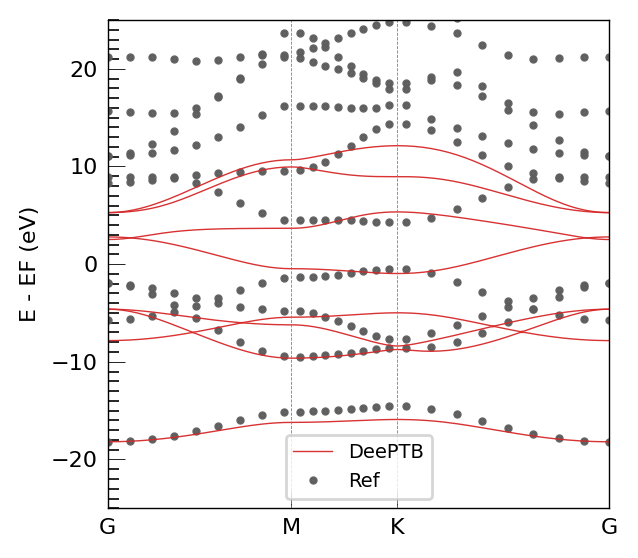

In [ ]:
jdata = j_loader("./run/band.json")
results_path = "./band_plot"
kpath_kwargs = jdata["task_options"]
stru_data = "./data/struct.vasp"
AtomicData_options = {"r_max": 5.0, "oer_max":1.6, "pbc": True}
structase = read(stru_data)
#data = AtomicData.from_ase(structase, **AtomicData_options)
#data = AtomicData.to_AtomicDataDict(data)
#data = model.idp(data)
bcal = Band(model=model, 
            use_gui=False, 
            results_path='./', 
            device=model.device)
eigenstatus = bcal.get_bands(data=stru_data, 
               kpath_kwargs=kpath_kwargs, 
               AtomicData_options=AtomicData_options)
bcal.band_plot(ref_band = kpath_kwargs["ref_band"],
               E_fermi = -2,
               emin = -25,
               emax = 25)

In [ ]:
r_max, er_max, oer_max

(None, None, None)

In [ ]:
from dptb.utils.argcheck import get_cutoffs_from_model_options
stru_data = "./data/struct.vasp"
r_max, er_max, oer_max  = get_cutoffs_from_model_options(model.model_options)
AtomicData_options = {"r_max": 5.0, "oer_max":1.6, "pbc": True}
structase = read(stru_data)
data = AtomicData.from_ase(structase, **AtomicData_options)
data = AtomicData.to_AtomicDataDict(data)
data = model.idp(data)
model.transform  = True 

In [ ]:
data = model(data)

In [ ]:
data['edge_features'].shape

torch.Size([48, 13])

In [ ]:
#1 + 
model.idp_sk.orbpair_maps

{'1s-1s': slice(0, 1, None),
 '1s-1p': slice(1, 2, None),
 '1p-1p': slice(2, 4, None)}